[Load] 正在读取数据: 3Dpano_from_txt_group0_2_9_loc_pred_DAS_fused_10files_triton.mat ...


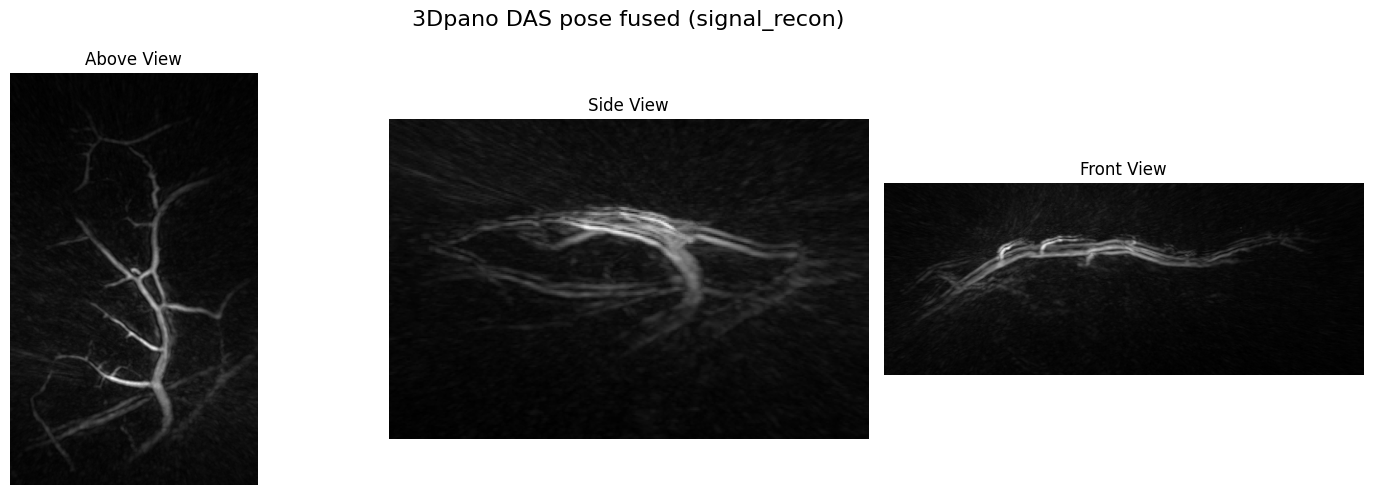

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ============ 1. 读取并处理 .mat 数据 =============
mat_path = '3Dpano_from_txt_group0_2_9_loc_pred_DAS_fused_10files_triton.mat'
# mat_path = 'recon_outputs_20260615_154954/3Dpano_group3_pose0_to_12_loc_pred_DAS_fused_13files_triton.mat'
# mat_path = 'Compensate_3Dpano_from_txt_group15_17_19_22_27_loc_pred_DAS_fused_5files.mat'
# mat_path = '3Dpano_from_txt_group15_17_19_22_27_loc_pred_DAS_fused_5files.mat'

if not os.path.exists(mat_path):
     raise FileNotFoundError(f"未找到数据文件: {mat_path}")

print(f"[Load] 正在读取数据: {mat_path} ...")
mat_data = loadmat(mat_path)

# 获取 'signal_recon' 变量
signal_recon = mat_data.get('signal_recon')
if signal_recon is None:
    raise ValueError(f"在 {mat_path} 文件中未找到 'signal_recon' 变量")

# 坐标变换 (保持与原代码一致的视角调整)
signal_recon = np.flip(signal_recon, axis=1)
signal_recon = np.transpose(signal_recon, (2, 1, 0))
signal_recon = np.flip(signal_recon, axis=1)

# 去除负值
signal_recon[signal_recon < 0] = 0

# ============ 2. 归一化与投影 (MIP) =============
# 归一化到 [0, 1]
if signal_recon.max() != 0:
    data_norm = signal_recon / signal_recon.max()
else:
    data_norm = signal_recon

# 最大强度投影 (MIP) - 并翻转 axis=0 以匹配视觉习惯
mip_above = np.flip(np.max(data_norm, axis=0), axis=0)
mip_side  = np.flip(np.max(data_norm, axis=1), axis=0)
mip_front = np.flip(np.max(data_norm, axis=2), axis=0)

# ============ 3. 绘制 1×3 子图 =============
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 绘制三个视角的投影图
axes[0].imshow(mip_above, cmap='gray')
axes[0].set_title('Above View')

axes[1].imshow(mip_side,  cmap='gray')
axes[1].set_title('Side View')

axes[2].imshow(mip_front, cmap='gray')
axes[2].set_title('Front View')

# 隐藏坐标轴
for ax in axes:
    ax.axis('off')

plt.suptitle('3Dpano DAS pose fused (signal_recon)', fontsize=16)
# plt.suptitle('3Dpano DAS pose60 (signal_recon)', fontsize=16)
plt.tight_layout()
plt.show()